# Day 2: Ridge & Lasso 回归 — L1/L2 正则化对比

把 House Prices 全部 79 维特征处理干净（数值填充 + 序数编码 + 独热编码），推到 200+ 维，
在同一起跑线上对比 LinearRegression vs Ridge vs Lasso。

- **Ridge (L2)**：压缩所有权重，但不归零
- **Lasso (L1)**：可以把不重要特征的权重精确变成 0

In [1]:
import sys; sys.path.append("..")  # 把上级目录加入路径，让 Python 能找到 models/ 文件夹
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from models.ridge_regression import RidgeRegression
from models.lasso_regression import LassoRegression

In [2]:
df = pd.read_csv("../data/train.csv")
y = np.log1p(df["SalePrice"].values)
df = df.drop(columns=["Id", "SalePrice"])
print(f"Raw: {df.shape[1]} features, {len(df)} samples")

Raw: 79 features, 1460 samples


## 1. 特征工程：从 79 列到 200+ 维

In [3]:
# 1a. 数值型 — 中位数填充缺失
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X_num_list = []
for c in num_cols:
    col = df[c].copy(); col.fillna(col.median(), inplace=True)
    X_num_list.append(col.values.astype(np.float64))
X_num = np.column_stack(X_num_list)
print(f"Numerical: {X_num.shape[1]} features")


Numerical: 36 features


In [4]:
# 1b. 序数型 — 映射为数值 (如 Ex=5, Gd=4, TA=3, Fa=2, Po=1)
quality_map = {'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1}
bsmt_map = {'GLQ':6,'ALQ':5,'BLQ':4,'Rec':3,'LwQ':2,'Unf':1}
ordinal_config = {
    'ExterQual':quality_map,'ExterCond':quality_map,
    'BsmtQual':quality_map,'BsmtCond':quality_map,
    'KitchenQual':quality_map,'FireplaceQu':quality_map,
    'GarageQual':quality_map,'GarageCond':quality_map,
    'HeatingQC':quality_map,'PoolQC':quality_map,
    'BsmtExposure':{'Gd':4,'Av':3,'Mn':2,'No':1},
    'BsmtFinType1':bsmt_map,'BsmtFinType2':bsmt_map,
    'GarageFinish':{'Fin':3,'RFn':2,'Unf':1},
    'Functional':{'Typ':7,'Min1':6,'Min2':5,'Mod':4,'Maj1':3,'Maj2':2,'Sev':1,'Sal':0},
    'CentralAir':{'Y':1,'N':0},'PavedDrive':{'Y':3,'P':2,'N':1},
    'LotShape':{'Reg':4,'IR1':3,'IR2':2,'IR3':1},
    'LandSlope':{'Gtl':3,'Mod':2,'Sev':1},
    'Utilities':{'AllPub':1,'NoSeWa':0},'Street':{'Pave':1,'Grvl':0},
    'Fence':{'GdPrv':4,'MnPrv':3,'GdWo':2,'MnWw':1},
}
X_ord_list = []
for c, m in ordinal_config.items():
    col = df[c].copy(); col.fillna('None', inplace=True)
    X_ord_list.append(col.map(m).fillna(0).values.astype(np.float64))
X_ord = np.column_stack(X_ord_list)
print(f"Ordinal: {X_ord.shape[1]} features")


Ordinal: 22 features


In [5]:
# 1c. 名义型 — 独热编码
nominal_cols = [c for c in df.columns if c not in num_cols and c not in ordinal_config]
X_ohe_list, ohe_names = [], []
for c in nominal_cols:
    col = df[c].copy(); col.fillna('None', inplace=True)
    for cat in sorted(col.unique()):
        X_ohe_list.append((col.values == cat).astype(np.float64))
        ohe_names.append(f'{c}_{cat}')
X_ohe = np.column_stack(X_ohe_list) if X_ohe_list else np.empty((len(df), 0))
print(f"OHE: {X_ohe.shape[1]} features")


OHE: 166 features


In [6]:
# 1d. 合并
X_all = np.column_stack([X_num, X_ord, X_ohe])
all_names = num_cols + list(ordinal_config.keys()) + ohe_names
print(f"Total: {X_all.shape[1]} features, {len(X_all)} samples")


Total: 224 features, 1460 samples


In [7]:
# 1e. 拆分 + 标准化
def standardize(train, test):
    mean, std = train.mean(0), train.std(0); std[std==0] = 1
    return (train-mean)/std, (test-mean)/std
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42)
X_train, X_test = standardize(X_train, X_test)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (1168, 224), Test: (292, 224)


## 2. 评估函数

In [8]:
def evaluate(model, X, y):
    y_pred = model.predict(X)
    rmse = np.sqrt(np.mean((y - y_pred)**2))
    ss_res, ss_tot = np.sum((y-y_pred)**2), np.sum((y-y.mean())**2)
    return rmse, 1 - ss_res/ss_tot


## 3. LinearRegression（基线）

使用 Ridge(α=0) 等价于普通线性回归。

In [9]:
lr = RidgeRegression(lr=0.01, epochs=2000, alpha=0)
lr.fit(X_train, y_train)
_, r2_lr_tr = evaluate(lr, X_train, y_train)
_, r2_lr_te = evaluate(lr, X_test, y_test)
print(f'LinearRegression - Train R2: {r2_lr_tr:.4f}, Test R2: {r2_lr_te:.4f}')

LinearRegression - Train R2: 0.9388, Test R2: 0.9198


## 4. Ridge 回归：不同 α 扫描

观察 L2 正则化强度对权重和泛化效果的影响。

In [10]:
ridge_alphas = [0, 0.01, 0.1, 1, 10, 100]
print(f"{'alpha':<8} {'Train R2':<10} {'Test R2':<10} {'||w||2':<10}")
print('-'*40)
ridge_results = []
for a in ridge_alphas:
    m = RidgeRegression(lr=0.01, epochs=2000, alpha=a)
    m.fit(X_train, y_train)
    _, r2_tr = evaluate(m, X_train, y_train)
    _, r2_te = evaluate(m, X_test, y_test)
    wn = np.linalg.norm(m.w)
    ridge_results.append((a, r2_tr, r2_te, wn))
    print(f'{a:<8} {r2_tr:<10.4f} {r2_te:<10.4f} {wn:<10.4f}')


alpha    Train R2   Test R2    ||w||2    
----------------------------------------


0        0.9388     0.9198     0.1834    


0.01     0.9387     0.9203     0.1796    


0.1      0.9361     0.9212     0.1576    


1        0.9038     0.8942     0.1091    


10       0.6996     0.6840     0.0561    


100      0.1974     0.1839     0.0118    


## 5. Lasso 回归：不同 α 扫描

观察 L1 正则化能否将不重要特征的权重归零。
注意 Lasso 的 α 通常比 Ridge 小一个数量级，因为 L1 惩罚力度更强。

In [11]:
lasso_alphas = [0, 0.0001, 0.001, 0.01, 0.1, 1]
print(f"{'alpha':<10} {'Train R2':<10} {'Test R2':<10} {'||w||1':<10} {'w≈0':<10}")
print('-'*50)
lasso_results = []
for a in lasso_alphas:
    m = LassoRegression(lr=0.01, epochs=2000, alpha=a)
    m.fit(X_train, y_train)
    _, r2_tr = evaluate(m, X_train, y_train)
    _, r2_te = evaluate(m, X_test, y_test)
    wn = np.sum(np.abs(m.w))
    nz = np.sum(np.abs(m.w) < 1e-4)
    lasso_results.append((a, r2_tr, r2_te, wn, nz))
    print(f'{a:<10} {r2_tr:<10.4f} {r2_te:<10.4f} {wn:<10.4f} {nz:<10}')


alpha      Train R2   Test R2    ||w||1     w≈0       
--------------------------------------------------


0          0.9388     0.9198     1.6313     3         


0.0001     0.9387     0.9204     1.5686     11        


0.001      0.9371     0.9238     1.2825     56        


0.01       0.9126     0.9077     0.7619     143       


0.1        0.7021     0.7082     0.3774     21        


1          0.0786     0.0461     1.1126     4         


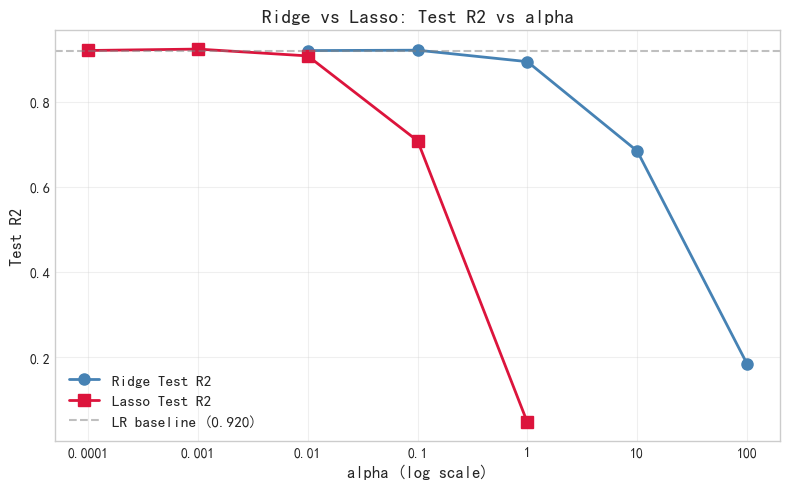

In [12]:
# Ridge vs Lasso: R2 vs alpha
ridge_alphas_arr = [r[0] for r in ridge_results if r[0] > 0]
ridge_r2_test = [r[2] for r in ridge_results if r[0] > 0]
lasso_alphas_arr = [r[0] for r in lasso_results if r[0] > 0]
lasso_r2_test = [r[2] for r in lasso_results if r[0] > 0]

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ridge_alphas_arr, ridge_r2_test, "o-", color="steelblue", markersize=8, linewidth=2, label="Ridge Test R2")
ax.plot(lasso_alphas_arr, lasso_r2_test, "s-", color="crimson", markersize=8, linewidth=2, label="Lasso Test R2")
ax.axhline(y=r2_lr_te, color="gray", linestyle="--", alpha=0.5, label=f"LR baseline ({r2_lr_te:.3f})")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.4g}"))
ax.set_xlabel("alpha (log scale)", fontsize=12)
ax.set_ylabel("Test R2", fontsize=12)
ax.set_title("Ridge vs Lasso: Test R2 vs alpha", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 权重可视化对比

选三个代表性模型，观察权重分布差异。

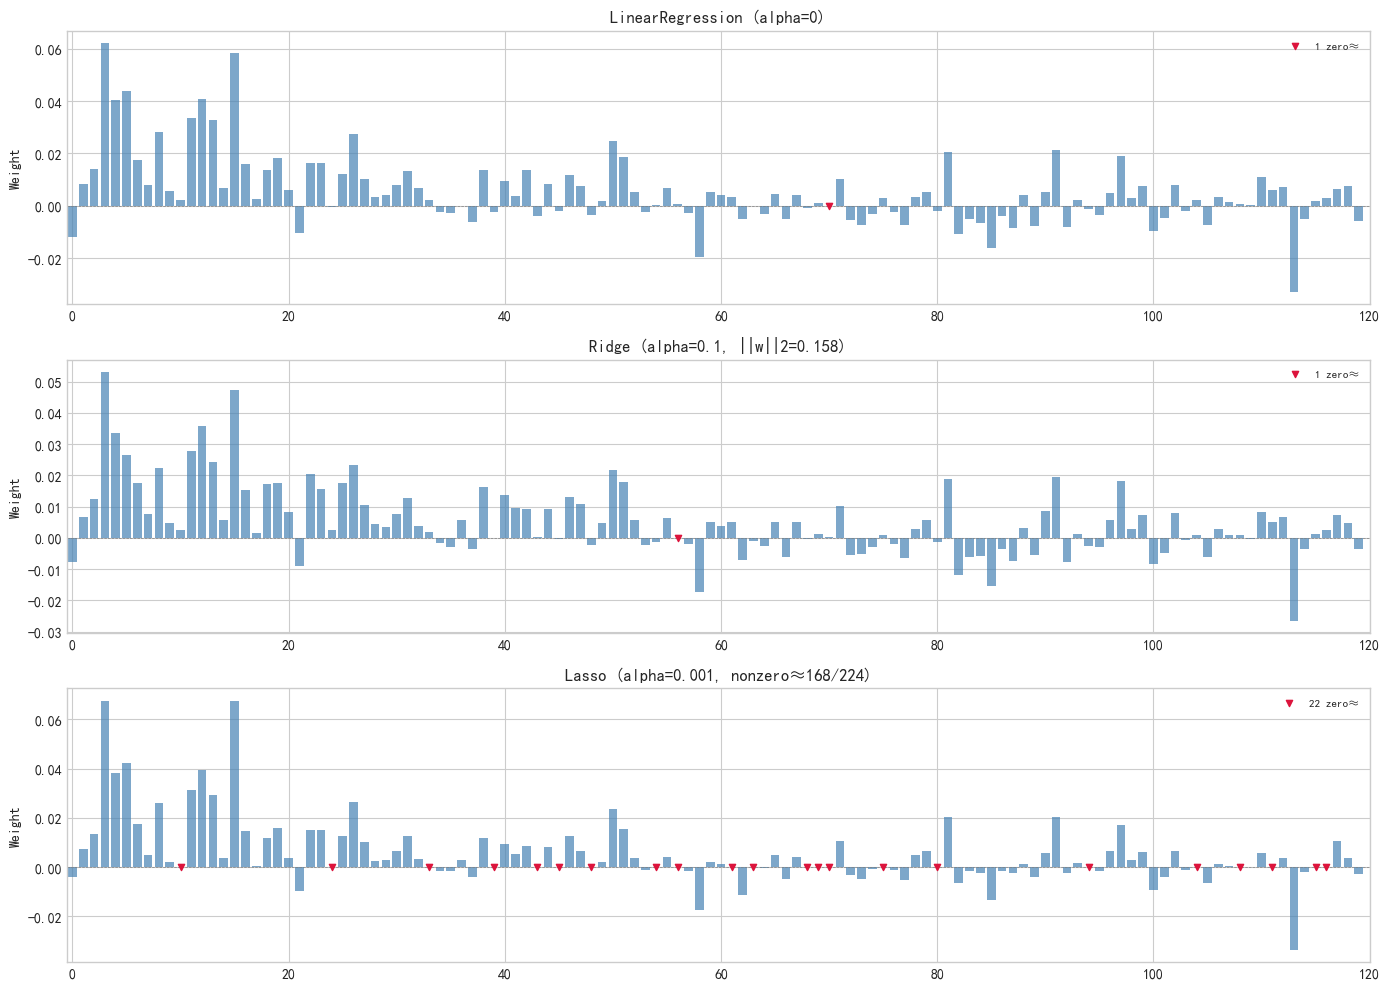

In [18]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 选最有代表性的模型
ridge_best = RidgeRegression(lr=0.01, epochs=2000, alpha=0.1)
ridge_best.fit(X_train, y_train)
lasso_best = LassoRegression(lr=0.01, epochs=2000, alpha=0.001)
lasso_best.fit(X_train, y_train)

# 展示前 120 个特征（覆盖到 OHE 区域，Lasso 的零权重更明显）
n_show = 120
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for ax, model, title in [
    (axes[0], lr, 'LinearRegression (alpha=0)'),
    (axes[1], ridge_best, f'Ridge (alpha=0.1, ||w||2={np.linalg.norm(ridge_best.w):.3f})'),
    (axes[2], lasso_best, f'Lasso (alpha=0.001, nonzero≈{np.sum(np.abs(lasso_best.w)>1e-4)}/{len(lasso_best.w)})'),
]:
    weights = model.w[:n_show]
    colors = ['crimson' if abs(w) < 1e-4 else 'steelblue' for w in weights]
    ax.bar(range(n_show), weights, color=colors, alpha=0.7)
    # 接近零的权重柱高≈0，加红色倒三角标记使其可见
    zero_idx = np.where(np.abs(weights) < 1e-4)[0]
    if len(zero_idx) > 0:
        ax.scatter(zero_idx, np.zeros_like(zero_idx), color='crimson',
                   marker='v', s=20, zorder=5, label=f'{len(zero_idx)} zero≈')
    ax.axhline(y=0, color='gray', ls='--', lw=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Weight')
    ax.set_xlim(-0.5, n_show)
    if len(zero_idx) > 0:
        ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

## 7. 结果汇总

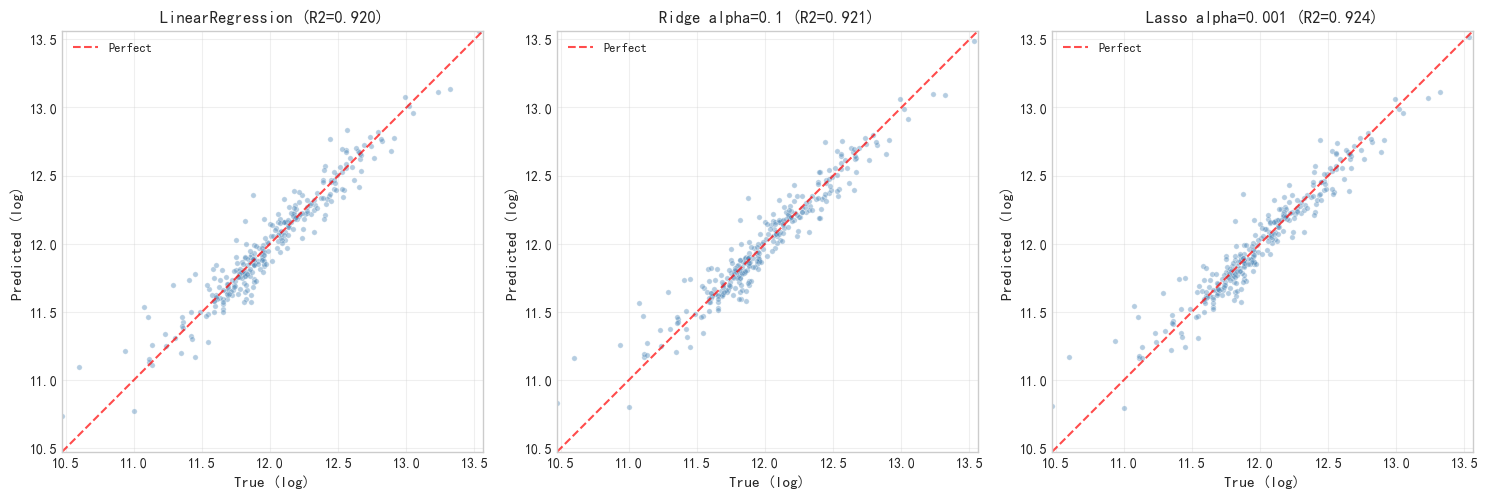

In [14]:
# True vs predicted scatter
y_pred_lr = lr.predict(X_test)
_, r2_ridge_te = evaluate(ridge_best, X_test, y_test)
_, r2_lasso_te = evaluate(lasso_best, X_test, y_test)
y_pred_ridge = ridge_best.predict(X_test)
y_pred_lasso = lasso_best.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

all_vals = np.concatenate([y_test, y_pred_lr, y_pred_ridge, y_pred_lasso])
lo, hi = all_vals.min(), all_vals.max()

for ax, yp, title in [
    (axes[0], y_pred_lr, f"LinearRegression (R2={r2_lr_te:.3f})"),
    (axes[1], y_pred_ridge, f"Ridge alpha=0.1 (R2={r2_ridge_te:.3f})"),
    (axes[2], y_pred_lasso, f"Lasso alpha=0.001 (R2={r2_lasso_te:.3f})"),
]:
    ax.scatter(y_test, yp, alpha=0.4, s=15, color="steelblue", edgecolors="white", linewidth=0.5)
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, alpha=0.7, label="Perfect")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("True (log)", fontsize=11)
    ax.set_ylabel("Predicted (log)", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_aspect("equal"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [15]:
best_ridge = max(ridge_results, key=lambda x: x[2])
best_lasso = max(lasso_results, key=lambda x: x[2])
print('='*60)
print(f"{'Model':<20} {'Test R2':<10} {'说明'}")
print('='*60)
print(f"{'LinearRegression':<20} {r2_lr_te:<10.4f} {'基线'}")
print(f"{'Ridge(alpha='+str(best_ridge[0])+')':<20} {best_ridge[2]:<10.4f} {'权重压缩，略微提升'}")
print(f"{'Lasso(alpha='+str(best_lasso[0])+')':<20} {best_lasso[2]:<10.4f} {'权重稀疏化，略微提升'}")
print('='*60)
print(f"{X_all.shape[1]}维 vs 之前的14维: R2 从 ~0.87 提升到 0.92+")
print(f"Ridge和Lasso的提升不大：因为1:5的特征/样本比，模型没过拟合")


Model                Test R2    说明
LinearRegression     0.9198     基线
Ridge(alpha=0.1)     0.9212     权重压缩，略微提升
Lasso(alpha=0.001)   0.9238     权重稀疏化，略微提升
224维 vs 之前的14维: R2 从 ~0.87 提升到 0.92+
Ridge和Lasso的提升不大：因为1:5的特征/样本比，模型没过拟合
